## Lineær Algebra – Konsepter

In [13]:
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    "text.color":        "black",
    "axes.labelcolor":   "black",
    "axes.edgecolor":    "#aaaaaa",
    "xtick.color":       "#aaaaaa",
    "ytick.color":       "#aaaaaa",
    "grid.color":        "#e8e8e3",
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#dddddd",
})

## Hvordan matrisen forvrenger vektorrommet

In [14]:
import matplotlib.pyplot as plt
plt.close('all')

import ipywidgets as widgets
from IPython.display import display

def plot_transform(a, b, c, d, vx, vy):
    A = np.array([[a, b], [c, d]])
    v = np.array([vx, vy])
    Av = A @ v

    fig = go.Figure()

    # Originalt rutenett
    for i in range(-4, 5):
        fig.add_trace(go.Scatter(x=[i,i], y=[-4,4], mode='lines',
            line=dict(color='rgba(102, 98, 116, 1)', width=1), showlegend=False, hoverinfo='skip'))
        fig.add_trace(go.Scatter(x=[-4,4], y=[i,i], mode='lines',
            line=dict(color='rgba(102, 98, 116, 1)', width=1), showlegend=False, hoverinfo='skip'))

    # Transformert rutenett
    for i in range(-4, 5):
        p1, p2 = A @ [i,-4], A @ [i, 4]
        p3, p4 = A @ [-4, i], A @ [4, i]
        fig.add_trace(go.Scatter(x=[p1[0],p2[0]], y=[p1[1],p2[1]], mode='lines',
            line=dict(color='rgba(215, 0, 47, 0.92)', width=1), showlegend=False, hoverinfo='skip'))
        fig.add_trace(go.Scatter(x=[p3[0],p4[0]], y=[p3[1],p4[1]], mode='lines',
            line=dict(color='rgba(215, 0, 47, 0.92)', width=1), showlegend=False, hoverinfo='skip'))

    def add_arrow(x1, y1, color, name, dash='solid'):
        fig.add_annotation(x=x1, y=y1, ax=0, ay=0,
            xref='x', yref='y', axref='x', ayref='y',
            showarrow=True, arrowhead=3, arrowsize=1.5,
            arrowwidth=2.5, arrowcolor=color)
        fig.add_trace(go.Scatter(x=[None], y=[None], mode='lines',
            line=dict(color=color, width=3, dash=dash), name=name))

    add_arrow(a, c, '#3b6d11', f"î' = [{a:.1f}, {c:.1f}]")
    add_arrow(b, d, '#854f0b', f"ĵ' = [{b:.1f}, {d:.1f}]")
    add_arrow(vx, vy, '#7f77dd', f'v = [{vx:.1f}, {vy:.1f}]', dash='dash')
    add_arrow(Av[0], Av[1], '#533ab7', f'Av = [{Av[0]:.2f}, {Av[1]:.2f}]')

    fig.update_layout(
        title=f'A = [[{a:.1f}, {b:.1f}], [{c:.1f}, {d:.1f}]]',
        xaxis=dict(range=[-5,5], zeroline=True, zerolinewidth=1.5, zerolinecolor='gray', scaleanchor='y'),
        yaxis=dict(range=[-5,5], zeroline=True, zerolinewidth=1.5, zerolinecolor='gray'),
        width=600, height=600, legend=dict(x=1.02, y=1)
    )
    fig.show()

style  = {'description_width': '140px'}
layout = widgets.Layout(width='380px')

sliders = {
    'a': widgets.FloatSlider(value=1, min=-3, max=3, step=0.1, description='a  (î → x)', style=style, layout=layout),
    'b': widgets.FloatSlider(value=0, min=-3, max=3, step=0.1, description='b  (ĵ → x)', style=style, layout=layout),
    'c': widgets.FloatSlider(value=0, min=-3, max=3, step=0.1, description='c  (î → y)', style=style, layout=layout),
    'd': widgets.FloatSlider(value=1, min=-3, max=3, step=0.1, description='d  (ĵ → y)', style=style, layout=layout),
    'vx': widgets.FloatSlider(value=2, min=-3, max=3, step=0.1, description='v_x', style=style, layout=layout),
    'vy': widgets.FloatSlider(value=1, min=-3, max=3, step=0.1, description='v_y', style=style, layout=layout),
}

ui = widgets.VBox([
    widgets.HTML('<b>Matrise A</b>'),
    widgets.HBox([sliders['a'], sliders['b']]),
    widgets.HBox([sliders['c'], sliders['d']]),
    widgets.HTML('<b>Vektor v</b>'),
    widgets.HBox([sliders['vx'], sliders['vy']]),
])

out = widgets.interactive_output(plot_transform, sliders)
display(ui, out)

Output()

## Determinanten

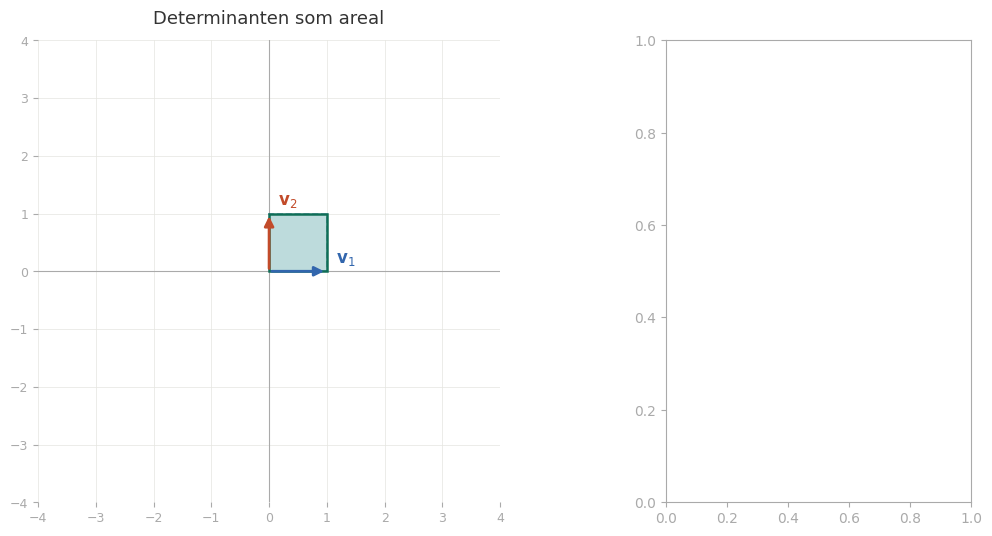

interactive(children=(FloatSlider(value=1.0, description='a', max=3.0, min=-3.0), FloatSlider(value=0.0, descr…

<function __main__.plot_determinant(a=1.0, b=0.0, c=0.0, d=1.0)>

In [15]:
import matplotlib.pyplot as plt
plt.close('all')

from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings("ignore")

def plot_determinant(a=1.0, b=0.0, c=0.0, d=1.0):
    _, axes = plt.subplots(1, 2, figsize=(13, 6),
                             gridspec_kw={"width_ratios": [2, 1]})
    ax = axes[0]
    ax_info = axes[1]

    # --- Beregn determinant ---
    det = a * d - b * c

    # --- Grid og akser ---
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.axhline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
    ax.axvline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
    for i in range(-4, 5):
        ax.axhline(i, color="#e5e5e0", linewidth=0.5, zorder=0)
        ax.axvline(i, color="#e5e5e0", linewidth=0.5, zorder=0)
    ax.set_xticks(range(-4, 5))
    ax.set_yticks(range(-4, 5))
    ax.tick_params(labelsize=9, color="#aaaaaa")
    for spine in ax.spines.values():
        spine.set_visible(False)

    # --- Opprinnelig enhetsfirkant (stiplet) ---
    unit_square = plt.Polygon(
        [[0, 0], [1, 0], [1, 1], [0, 1]],
        closed=True,
        facecolor="#3266ad22",
        edgecolor="#3266ad88",
        linewidth=1.2,
        linestyle="--",
        zorder=2
    )
    ax.add_patch(unit_square)

    # --- Transformert parallelogram ---
    corners = np.array([[0, 0], [a, c], [a + b, c + d], [b, d]])
    fill_color = "#1d9e7530" if det >= 0 else "#d85a3030"
    edge_color = "#0f6e56" if det >= 0 else "#993c1d"
    parallelogram = plt.Polygon(
        corners,
        closed=True,
        facecolor=fill_color,
        edgecolor=edge_color,
        linewidth=1.8,
        zorder=3
    )
    ax.add_patch(parallelogram)

    # --- Kolonnvektorer ---
    arrow_kw = dict(arrowstyle="-|>", mutation_scale=14,
                    linewidth=2, zorder=5)
    ax.annotate("", xy=(a, c), xytext=(0, 0),
                arrowprops=dict(**arrow_kw, color="#3266ad"))
    ax.annotate("", xy=(b, d), xytext=(0, 0),
                arrowprops=dict(**arrow_kw, color="#c24b2a"))

    # Etiketter på vektorer
    offset = 0.15
    ax.text(a + offset, c + offset, r"$\mathbf{v}_1$",
            color="#3266ad", fontsize=12, fontweight="bold", zorder=6)
    ax.text(b + offset, d + offset, r"$\mathbf{v}_2$",
            color="#c24b2a", fontsize=12, fontweight="bold", zorder=6)

    # --- Tittel og akseetiketter ---
    ax.set_title("Determinanten som areal", fontsize=13, pad=12,
                 color="#333333", fontweight="normal")

    # --- Legende ---
    legend_elements = [
        mpatches.Patch(facecolor="#3266ad22", edgecolor="#3266ad88",
                       linestyle="--", label="Enhetsfirkant (areal = 1)"),
        mpatches.Patch(facecolor=fill_color, edgecolor=edge_color,
                       label=f"Transformert parallelogram (areal = {abs(det):.2f})"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#dddddd")

    # --- Informasjonspanel (høyre) ---
    ax_info.axis("off")
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)

    # Matrisen
    ax_info.text(0.5, 0.95, "Matrise A", ha="center", va="top",
                 fontsize=11, color="#555555")
    ax_info.text(0.5, 0.87,
                 f"⎡ {a:+.1f}   {b:+.1f} ⎤\n⎣ {c:+.1f}   {d:+.1f} ⎦",
                 ha="center", va="top", fontsize=12,
                 fontfamily="monospace", color="#222222",
                 linespacing=1.8)

    # Determinantformel
    ax_info.text(0.5, 0.67, "det(A) = ad − bc", ha="center", va="top",
                 fontsize=10, color="#777777", style="italic")
    ax_info.text(0.5, 0.59,
                 f"= ({a:.1f})({d:.1f}) − ({b:.1f})({c:.1f})",
                 ha="center", va="top", fontsize=10,
                 fontfamily="monospace", color="#555555")

    det_color = "#0f6e56" if det > 0.001 else "#993c1d" if det < -0.001 else "#888888"
    ax_info.text(0.5, 0.50, f"= {det:.2f}",
                 ha="center", va="top", fontsize=22,
                 fontweight="bold", color=det_color)

    # Tolkning
    if abs(det) < 0.01:
        label = "Singulær — kolonnene er\nlineært avhengige"
        label_color = "#888888"
    elif det < 0:
        label = "Negativ — orientasjonen\ner snudd"
        label_color = "#993c1d"
    else:
        label = "Positiv — orientasjonen\ner bevart"
        label_color = "#0f6e56"

    ax_info.text(0.5, 0.38, label, ha="center", va="top",
                 fontsize=10, color=label_color, linespacing=1.5)

    # Arealsammenligning
    ax_info.axhline(0.27, color="#dddddd", linewidth=0.8)
    ax_info.text(0.5, 0.24, "Arealskalering", ha="center", va="top",
                 fontsize=10, color="#555555")
    ax_info.text(0.5, 0.16, f"1.00  →  {abs(det):.2f}",
                 ha="center", va="top", fontsize=13,
                 fontfamily="monospace", color="#222222")
    ax_info.text(0.5, 0.08, f"|det(A)| = {abs(det):.2f}",
                 ha="center", va="top", fontsize=10,
                 color="#888888", style="italic")

    plt.tight_layout(pad=2.0)
    plt.show()


# Interaktive slidere
slider_kw = dict(min=-3.0, max=3.0, step=0.1, continuous_update=True)
interact(
    plot_determinant,
    a=FloatSlider(value=1.0, description="a", **slider_kw),
    b=FloatSlider(value=0.0, description="b", **slider_kw),
    c=FloatSlider(value=0.0, description="c", **slider_kw),
    d=FloatSlider(value=1.0, description="d", **slider_kw),
)

## De fire underrommene

In [16]:
import matplotlib.pyplot as plt
plt.close('all')

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sympy import Matrix
from IPython.display import display, Math, Markdown

A = Matrix([[1, 1, 2],
            [2, 1, 3],
            [3, 2, 5]])

rref_A, pivots = A.rref()
r = len(pivots)

null_vecs  = A.nullspace()
left_null  = A.T.nullspace()
row_basis  = [np.array(rref_A.row(i).tolist()[0], dtype=float) for i in range(r)]
col_basis  = [np.array(A.col(i).tolist(), dtype=float).flatten() for i in pivots]
n_vec      = np.array(null_vecs[0].tolist(), dtype=float).flatten()
ln_vec     = np.array(left_null[0].tolist(), dtype=float).flatten()

n_vec  /= np.linalg.norm(n_vec)
ln_vec /= np.linalg.norm(ln_vec)

display(Math(r'A = ' + str(A.tolist()).replace('[','\\begin{bmatrix}').replace(']','\\end{bmatrix}')))
display(Markdown(f"Rang $r$ = **{r}**, nullitet = **{3 - r}**"))

def plane_traces(basis_vecs, color, name, opacity=0.35):
    b1, b2 = basis_vecs[0], basis_vecs[1]
    s = t = np.linspace(-1.5, 1.5, 30)
    S, T = np.meshgrid(s, t)
    X = S * b1[0] + T * b2[0]
    Y = S * b1[1] + T * b2[1]
    Z = S * b1[2] + T * b2[2]
    return go.Surface(x=X, y=Y, z=Z,
                      colorscale=[[0, color], [1, color]],
                      opacity=opacity, showscale=False,
                      name=name, showlegend=True,
                      hoverinfo='skip')

def line_trace(direction, color, name, width=6):
    t = np.linspace(-1.8, 1.8, 50)
    d = direction / np.linalg.norm(direction)
    return go.Scatter3d(
        x=t*d[0], y=t*d[1], z=t*d[2],
        mode='lines',
        line=dict(color=color, width=width),
        name=name
    )

def vector_trace(vec, color, name):
    v = vec / np.linalg.norm(vec) * 1.2
    return go.Scatter3d(
        x=[0, v[0]], y=[0, v[1]], z=[0, v[2]],
        mode='lines+markers',
        line=dict(color=color, width=5),
        marker=dict(size=[0, 6], color=color),
        name=name
    )

def axis_layout(title):
    return dict(
        title=title,
        range=[-2, 2],
        showbackground=True,
        gridcolor='rgba(180,180,180,0.5)',
        zerolinecolor='rgba(100,100,100,0.8)',
        zerolinewidth=2
    )

x_r = row_basis[0] * 0.8 + row_basis[1] * 0.5
x_r /= np.linalg.norm(x_r)
Ax_r = np.array((A * Matrix(x_r.tolist())).tolist(), dtype=float).flatten()
Ax_r /= np.linalg.norm(Ax_r)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=[
        'Domenet ℝⁿ — radrom og nullrom',
        'Kodomenet ℝᵐ — kolonnerom og venstre nullrom'
    ]
)

fig.add_trace(plane_traces(row_basis, '#3b8c3b', 'Radrom C(Aᵀ)'), row=1, col=1)
fig.add_trace(line_trace(n_vec, '#e07b00', 'Nullrom N(A)'), row=1, col=1)
fig.add_trace(vector_trace(x_r, '#6a3fc4', 'x_r ∈ radrom'), row=1, col=1)

fig.add_trace(plane_traces(col_basis, '#1a78c2', 'Kolonnerom C(A)'), row=1, col=2)
fig.add_trace(line_trace(ln_vec, '#c43a3a', 'Venstre nullrom N(Aᵀ)'), row=1, col=2)
fig.add_trace(vector_trace(Ax_r, '#6a3fc4', 'Ax_r ∈ kolonnerom'), row=1, col=2)

camera = dict(eye=dict(x=1.6, y=1.6, z=1.2))

fig.update_layout(
    height=600,
    title_text='De fire fundamentale underrommene (rotér gjerne)',
    title_x=0.5,
    legend=dict(x=1.05, y=0.9),
    scene=dict(
        xaxis=axis_layout('x₁'), yaxis=axis_layout('x₂'), zaxis=axis_layout('x₃'),
        camera=camera
    ),
    scene2=dict(
        xaxis=axis_layout('y₁'), yaxis=axis_layout('y₂'), zaxis=axis_layout('y₃'),
        camera=camera
    )
)

fig.show()

<IPython.core.display.Math object>

Rang $r$ = **2**, nullitet = **1**

## Egenvektorer/verdier

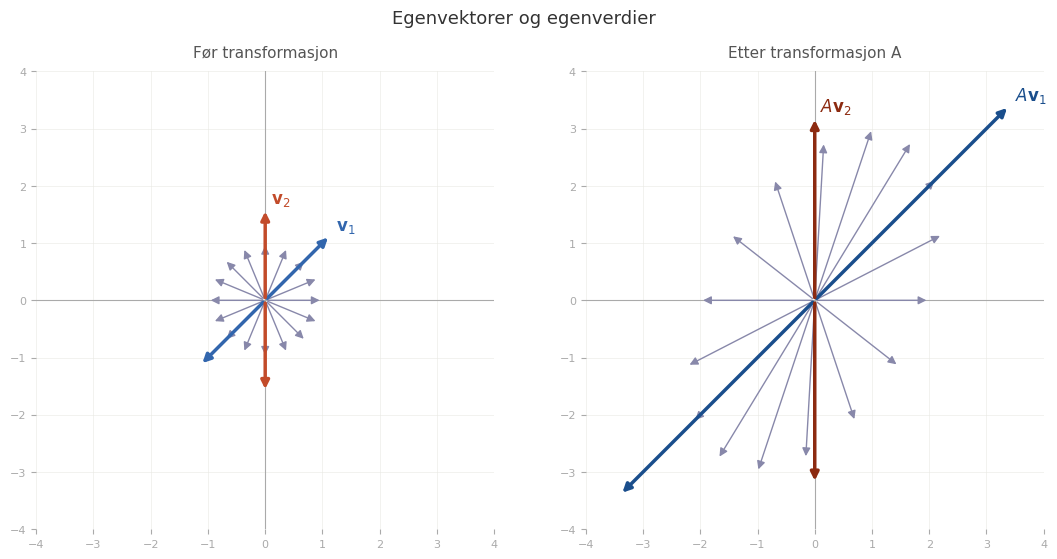

interactive(children=(FloatSlider(value=2.0, description='a', max=3.0, min=-3.0), FloatSlider(value=1.0, descr…

<function __main__.plot_eigenvectors(a=2.0, b=1.0, c=0.0, d=3.0)>

In [17]:
import matplotlib.pyplot as plt
plt.close('all')

from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings("ignore")


def compute_eigen(a, b, c, d):
    """Beregner egenverdier og egenvektorer analytisk for 2x2-matriser."""
    tr = a + d
    det = a * d - b * c
    disc = tr**2 - 4 * det
    if disc < 0:
        return None  # Komplekse egenverdier

    sq = np.sqrt(disc)
    l1, l2 = (tr + sq) / 2, (tr - sq) / 2

    def eigvec(lam):
        if abs(b) > 1e-9:
            v = np.array([lam - a, b])
        elif abs(c) > 1e-9:
            v = np.array([c, lam - d])
        elif abs(a - lam) < 1e-6:
            v = np.array([1.0, 0.0])
        else:
            v = np.array([0.0, 1.0])
        return v / np.linalg.norm(v)

    return {"l1": l1, "l2": l2, "v1": eigvec(l1), "v2": eigvec(l2)}


def draw_arrow(ax, x1, y1, x2, y2, color, lw=1.5, alpha=1.0):
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            mutation_scale=12,
        ),
        alpha=alpha,
    )


def plot_eigenvectors(a=2.0, b=1.0, c=0.0, d=3.0):
    A = np.array([[a, b], [c, d]])
    eigen = compute_eigen(a, b, c, d)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle("Egenvektorer og egenverdier", fontsize=13,
                 fontweight="normal", color="#333333", y=0.98)

    lim = 4
    N = 16  # Antall enhetsvektorer
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    unit_vecs = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    transformed = (A @ unit_vecs.T).T

    EV_COLORS = ["#3266ad", "#c24b2a"]
    EV_AFTER_COLORS = ["#1a4e8c", "#8c2a10"]
    GRAY = "#8888aa"

    for ax_idx, ax in enumerate(axes):
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.axhline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
        ax.axvline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
        for i in range(-lim, lim + 1):
            ax.axhline(i, color="#e8e8e3", linewidth=0.4, zorder=0)
            ax.axvline(i, color="#e8e8e3", linewidth=0.4, zorder=0)
        ax.set_xticks(range(-lim, lim + 1))
        ax.set_yticks(range(-lim, lim + 1))
        ax.tick_params(labelsize=8, colors="#aaaaaa")
        for spine in ax.spines.values():
            spine.set_visible(False)

        if ax_idx == 0:
            # Venstre panel: før transformasjon
            ax.set_title("Før transformasjon", fontsize=11,
                         pad=10, color="#555555", fontweight="normal")
            for v in unit_vecs:
                draw_arrow(ax, 0, 0, v[0], v[1],
                           color=GRAY, lw=1.0, alpha=0.5)
            if eigen:
                r = 1.6
                for vi, color in zip([eigen["v1"], eigen["v2"]], EV_COLORS):
                    for sign in [1, -1]:
                        draw_arrow(ax, 0, 0,
                                   sign * vi[0] * r, sign * vi[1] * r,
                                   color=color, lw=2.5)
                ax.text(eigen["v1"][0] * r + 0.1,
                        eigen["v1"][1] * r + 0.1,
                        r"$\mathbf{v}_1$", color=EV_COLORS[0],
                        fontsize=12, fontweight="bold")
                ax.text(eigen["v2"][0] * r + 0.1,
                        eigen["v2"][1] * r + 0.1,
                        r"$\mathbf{v}_2$", color=EV_COLORS[1],
                        fontsize=12, fontweight="bold")
        else:
            # Høyre panel: etter transformasjon
            ax.set_title("Etter transformasjon A", fontsize=11,
                         pad=10, color="#555555", fontweight="normal")
            for v in transformed:
                draw_arrow(ax, 0, 0, v[0], v[1],
                           color=GRAY, lw=1.0, alpha=0.5)
            if eigen:
                r = 1.6
                for vi, lam, col_bef, col_aft, label in zip(
                    [eigen["v1"], eigen["v2"]],
                    [eigen["l1"], eigen["l2"]],
                    EV_COLORS, EV_AFTER_COLORS,
                    [r"$A\mathbf{v}_1$", r"$A\mathbf{v}_2$"]
                ):
                    scaled = lam * r
                    for sign in [1, -1]:
                        if abs(scaled) > 0.05:
                            draw_arrow(ax, 0, 0,
                                       sign * vi[0] * scaled,
                                       sign * vi[1] * scaled,
                                       color=col_aft, lw=2.5)
                    tx = vi[0] * scaled + 0.1
                    ty = vi[1] * scaled + 0.1
                    ax.text(tx, ty, label, color=col_aft,
                            fontsize=12, fontweight="bold")

    # --- Matrise og egenverdier i tittelramme ---
    lam_str = ""
    ev_str = ""
    if eigen:
        l1, l2 = eigen["l1"], eigen["l2"]
        v1, v2 = eigen["v1"], eigen["v2"]
        lam_str = f"λ₁ = {l1:.2f},   λ₂ = {l2:.2f}"
        ev_str  = (f"v₁ = ({v1[0]:+.2f}, {v1[1]:+.2f})     "
                   f"v₂ = ({v2[0]:+.2f}, {v2[1]:+.2f})")
    else:
        lam_str = "Ingen reelle egenverdier (komplekse)"
        ev_str  = "Matrisen utfører en ren rotasjon — ingen faste akser"

    matrix_str = f"A = [[{a:.1f}, {b:.1f}], [{c:.1f}, {d:.1f}]]"

    legend_elements = [
        mpatches.Patch(color=GRAY, alpha=0.5, label="Tilfeldige enhetsvektorer"),
        mpatches.Patch(color=EV_COLORS[0], label=f"v₁  (λ₁ = {eigen['l1']:.2f})" if eigen else "v₁"),
        mpatches.Patch(color=EV_COLORS[1], label=f"v₂  (λ₂ = {eigen['l2']:.2f})" if eigen else "v₂"),
    ]
    axes[0].legend(handles=legend_elements, loc="upper right",
                   fontsize=9, framealpha=0.9, edgecolor="#dddddd")

    fig.text(0.5, 0.01,
             f"{matrix_str}     |     {lam_str}\n{ev_str}",
             ha="center", va="bottom", fontsize=9.5,
             color="#555555", fontfamily="monospace",
             linespacing=1.8)

    plt.tight_layout(rect=[0, 0.08, 1, 0.97])
    plt.show()


slider_kw = dict(min=-3.0, max=3.0, step=0.1, continuous_update=True)
interact(
    plot_eigenvectors,
    a=FloatSlider(value=2.0, description="a", **slider_kw),
    b=FloatSlider(value=1.0, description="b", **slider_kw),
    c=FloatSlider(value=0.0, description="c", **slider_kw),
    d=FloatSlider(value=3.0, description="d", **slider_kw),
)

## Komplekse egenverdier

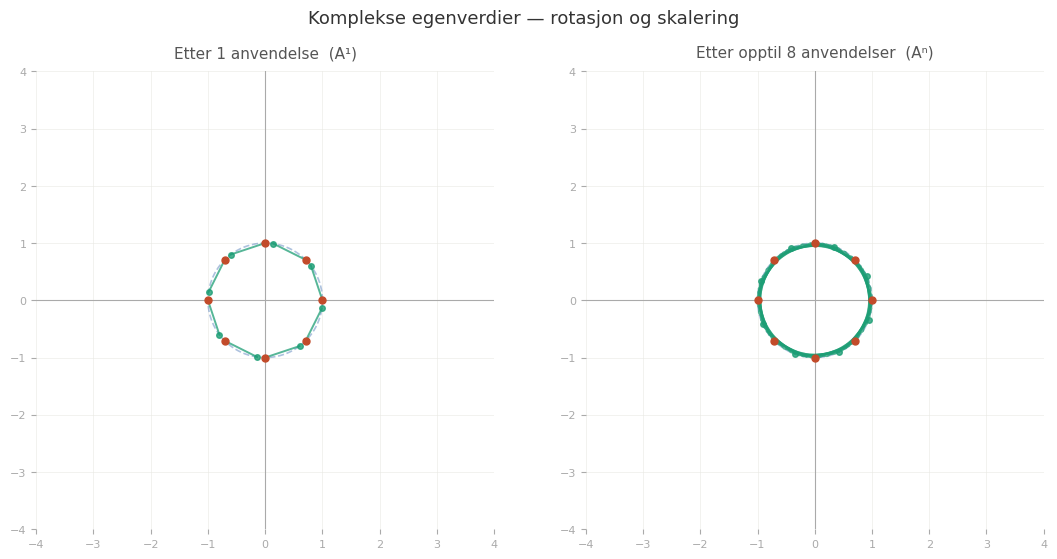

interactive(children=(FloatSlider(value=0.8, description='a', max=2.0, min=-2.0, step=0.05), FloatSlider(value…

<function __main__.plot_complex_eigenvalues(a=0.8, b=-0.6, c=0.6, d=0.8)>

In [18]:
import matplotlib.pyplot as plt
plt.close('all')

from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings("ignore")


def plot_complex_eigenvalues(a=0.8, b=-0.6, c=0.6, d=0.8):
    A = np.array([[a, b], [c, d]])
    tr = a + d
    det = a * d - b * c
    disc = tr**2 - 4 * det

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle("Komplekse egenverdier — rotasjon og skalering",
                 fontsize=13, fontweight="normal", color="#333333", y=0.98)

    N_points = 8
    N_steps  = 8
    lim      = 4
    angles   = np.linspace(0, 2 * np.pi, N_points, endpoint=False)
    starts   = np.stack([np.cos(angles), np.sin(angles)], axis=1)

    SPIRAL_COLOR = "#1d9e75"
    DOT_COLOR    = "#c24b2a"
    CIRCLE_COLOR = "#3266ad"

    titles = ["Etter 1 anvendelse  (A¹)", f"Etter opptil {N_steps} anvendelser  (Aⁿ)"]

    for ax_idx, ax in enumerate(axes):
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.axhline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
        ax.axvline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
        for i in range(-lim, lim + 1):
            ax.axhline(i, color="#e8e8e3", linewidth=0.4, zorder=0)
            ax.axvline(i, color="#e8e8e3", linewidth=0.4, zorder=0)
        ax.set_xticks(range(-lim, lim + 1))
        ax.set_yticks(range(-lim, lim + 1))
        ax.tick_params(labelsize=8, colors="#aaaaaa")
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title(titles[ax_idx], fontsize=11,
                     pad=10, color="#555555", fontweight="normal")

        # Enhetssirkel
        theta = np.linspace(0, 2 * np.pi, 300)
        ax.plot(np.cos(theta), np.sin(theta),
                color=CIRCLE_COLOR, linewidth=1.2,
                linestyle="--", alpha=0.4, zorder=2)

        steps = 1 if ax_idx == 0 else N_steps

        for v0 in starts:
            v = v0.copy()
            xs, ys = [v[0]], [v[1]]

            # Startpunkt
            ax.plot(v[0], v[1], "o", color=DOT_COLOR,
                    markersize=5, zorder=5)

            for _ in range(steps):
                v = A @ v
                if np.any(np.abs(v) > lim + 0.5):
                    break
                xs.append(v[0])
                ys.append(v[1])

            # Spor
            ax.plot(xs, ys, color=SPIRAL_COLOR,
                    linewidth=1.4, alpha=0.75, zorder=3)
            # Endepunkt
            if len(xs) > 1:
                ax.plot(xs[-1], ys[-1], "o", color=SPIRAL_COLOR,
                        markersize=4, alpha=0.8, zorder=4)

    # --- Legende ---
    legend_elements = [
        mpatches.Patch(color=CIRCLE_COLOR, alpha=0.4,
                       label="Enhetssirkel (startposisjon)"),
        plt.Line2D([0], [0], color=SPIRAL_COLOR, linewidth=1.8,
                   label="Spiralbane"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=DOT_COLOR, markersize=7,
                   label="Startpunkt"),
    ]
    axes[0].legend(handles=legend_elements, loc="upper right",
                   fontsize=9, framealpha=0.9, edgecolor="#dddddd")

    # --- Egenverdiinfo nederst ---
    if disc < 0:
        alpha = tr / 2
        beta  = np.sqrt(-disc) / 2
        mod   = np.sqrt(alpha**2 + beta**2)
        arg   = np.degrees(np.arctan2(beta, alpha))

        if mod > 1.005:
            beh = f"|λ| = {mod:.4f} > 1  →  spiral utover (ustabilt)"
        elif mod < 0.995:
            beh = f"|λ| = {mod:.4f} < 1  →  spiral innover (stabilt)"
        else:
            beh = f"|λ| = {mod:.4f} ≈ 1  →  stabil sirkelbane"

        info = (
            f"A = [[{a:.2f}, {b:.2f}], [{c:.2f}, {d:.2f}]]     "
            f"λ = {alpha:.3f} ± {beta:.3f}i\n"
            f"Rotasjon per steg: arg(λ) = {arg:.1f}°     "
            f"Skalering per steg: |λ| = {mod:.4f}     {beh}"
        )
    else:
        sq = np.sqrt(disc)
        l1, l2 = (tr + sq) / 2, (tr - sq) / 2
        info = (
            f"A = [[{a:.2f}, {b:.2f}], [{c:.2f}, {d:.2f}]]     "
            f"Reelle egenverdier: λ₁ = {l1:.3f},  λ₂ = {l2:.3f}\n"
            "Ingen komplekse egenverdier — juster matrisen slik at diskriminanten blir negativ"
        )

    fig.text(0.5, 0.01, info, ha="center", va="bottom",
             fontsize=9.5, color="#555555",
             fontfamily="monospace", linespacing=1.8)

    plt.tight_layout(rect=[0, 0.1, 1, 0.97])
    plt.show()


slider_kw = dict(min=-2.0, max=2.0, step=0.05, continuous_update=True)
interact(
    plot_complex_eigenvalues,
    a=FloatSlider(value=0.80, description="a", **slider_kw),
    b=FloatSlider(value=-0.60, description="b", **slider_kw),
    c=FloatSlider(value=0.60, description="c", **slider_kw),
    d=FloatSlider(value=0.80, description="d", **slider_kw),
)